# Proyecto NLP – Análisis de Sentimiento en Tweets  
## Orden de clase + nomenclatura pedida

**Nombres de datasets:**
- Dataset grande (0/4): `df_grande`
- Dataset chico (0/2/4): `df_small`

**Flujo como en clase:**
1. Cargar datasets  
2. EDA con texto crudo  
3. Split interno sobre `df_grande` → `X_train, X_test, y_train, y_test`  
4. Limpieza regex aplicada a `X_train`, `X_test` y `X_ext` por separado  
5. Lematización acelerada con cache (sobre textos limpios)  
6. Entrenar 2 modelos binarios (LR, NB), métricas Train/Test interno estilo clase  
7. Test externo `df_small` con neutral por descarte (3 clases)  
8. Baseline TextBlob + similitud coseno

> Mantengo esta nomenclatura hasta el final del TP.


In [2]:
# ===== 0. Imports =====
import os, re, numpy as np, pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

import matplotlib.pyplot as plt

# WordCloud
try:
    from wordcloud import WordCloud
except ImportError:
    print("Instalá wordcloud: pip install wordcloud")
!pip install wordcloud

# TextBlob
try:
    from textblob import TextBlob
    TEXTBLOB_AVAILABLE = True
except ImportError:
    TEXTBLOB_AVAILABLE = False
    print("Instalá textblob: pip install textblob")


## 0.1 Instalación (una sola vez)

In [3]:
!pip -q install spacy==3.7.2 wordcloud
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 15.8 MB/s eta 0:00:00a 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


## 1. Carga de datos

- `df_grande`: training.1600000.processed.noemoticon.csv  
- `df_small`:  testdata.manual.2009.06.14.csv


In [4]:
# ===== 1. Carga =====
path_grande = "training.1600000.processed.noemoticon.csv"
path_small  = "testdata.manual.2009.06.14.csv"
cols = ["polarity","id","date","query","user","text"]

df_grande = pd.read_csv(path_grande, encoding="latin-1", header=None, names=cols)
df_small  = pd.read_csv(path_small,  encoding="latin-1", header=None, names=cols)

print("df_grande shape:", df_grande.shape)
print("df_small  shape:", df_small.shape)
df_grande.head()


df_grande shape: (1600000, 6)
df_small  shape: (498, 6)


,polarity,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


## 2. EDA en crudo (antes de limpiar)

Selecciones que pediste:
1) eliminar columnas no informativas  
2) distribución conteo+proporción  
3) duplicados (medir y eliminar en df_grande)  
4) largo por clase  
8) wordcloud por clase en crudo


In [5]:
# ===== 2.1 eliminar columnas no informativas =====
df_grande = df_grande[["polarity","text"]].copy()
df_small  = df_small[["polarity","text"]].copy()
df_grande.head()


,polarity,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."



df_grande (crudo)
            count  prop
polarity              
0         800000   0.5
4         800000   0.5

df_small  (crudo)
           count   prop
polarity              
0           177  0.355
2           139  0.279
4           182  0.365


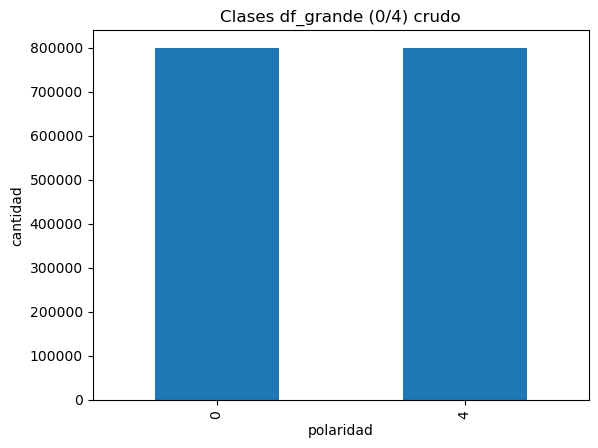

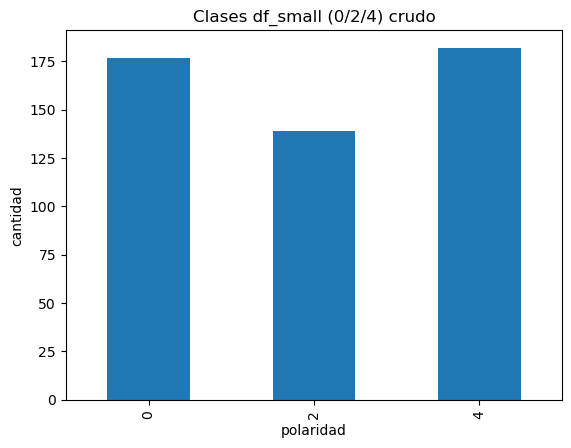

In [6]:
# ===== 2.2 distribución de clases =====
def class_stats(df, name):
    counts = df["polarity"].value_counts().sort_index()
    props  = (counts / counts.sum()).round(3)
    print(f"\n{name}\n", pd.DataFrame({"count": counts, "prop": props}))

class_stats(df_grande, "df_grande (crudo)")
class_stats(df_small,  "df_small  (crudo)")

def plot_class_distribution(df, title):
    counts = df["polarity"].value_counts().sort_index()
    plt.figure()
    counts.plot(kind="bar")
    plt.title(title)
    plt.xlabel("polaridad")
    plt.ylabel("cantidad")
    plt.show()

plot_class_distribution(df_grande, "Clases df_grande (0/4) crudo")
plot_class_distribution(df_small,  "Clases df_small (0/2/4) crudo")


In [7]:
# ===== 2.3 duplicados en df_grande (texto crudo) =====
before = len(df_grande)
df_grande = df_grande.drop_duplicates(subset=["text"])
print("Duplicados eliminados en df_grande:", before - len(df_grande))
class_stats(df_grande, "df_grande (sin duplicados)")


Duplicados eliminados en df_grande: 18534

df_grande (sin duplicados)
            count  prop
polarity              
0         790185   0.5
4         791281   0.5


In [ ]:
# ===== 2.4 largo de tweets por clase en crudo =====
df_grande["len_raw"] = df_grande["text"].astype(str).str.split().apply(len)
df_small["len_raw"]  = df_small["text"].astype(str).str.split().apply(len)

plt.figure()
df_grande.boxplot(column="len_raw", by="polarity")
plt.title("Largo por polaridad (df_grande crudo)")
plt.suptitle("")
plt.xlabel("polaridad")
plt.ylabel("tokens")
plt.show()

plt.figure()
df_small.boxplot(column="len_raw", by="polarity")
plt.title("Largo por polaridad (df_small crudo)")
plt.suptitle("")
plt.xlabel("polaridad")
plt.ylabel("tokens")
plt.show()


In [ ]:
# ===== 2.5 wordclouds en crudo =====
def wc_for_class_raw(df, label, pref=""):
    text = " ".join(df[df.polarity==label]["text"].astype(str)).lower()
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"{pref}WordCloud crudo clase {label}")
    plt.show()

wc_for_class_raw(df_grande, 0, "df_grande – ")
wc_for_class_raw(df_grande, 4, "df_grande – ")
wc_for_class_raw(df_small,  0, "df_small – ")
wc_for_class_raw(df_small,  2, "df_small – ")
wc_for_class_raw(df_small,  4, "df_small – ")


## 3. Split interno sobre df_grande (como en clase)
Split antes de limpiar/lematizar.


In [ ]:
X = df_grande["text"]
y = df_grande["polarity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)


## 4. Limpieza con regex (train/test interno + externo)

In [ ]:
url_re = re.compile(r"https?://\S+|www\.\S+")
mention_re = re.compile(r"@\w+")
hashtag_re = re.compile(r"#(\w+)")

def clean_tweet(text: str) -> str:
    text = str(text).lower()
    text = url_re.sub(" ", text)
    text = mention_re.sub(" ", text)
    text = hashtag_re.sub(r"\1", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

X_train_clean = X_train.apply(clean_tweet)
X_test_clean  = X_test.apply(clean_tweet)

X_ext = df_small["text"]
y_ext = df_small["polarity"]
X_ext_clean = X_ext.apply(clean_tweet)


## 5. Lematización acelerada con cache (sobre textos limpios)

In [ ]:
import spacy
from spacy.lang.en.stop_words import STOP_WORDS

nlp = spacy.load("en_core_web_sm", disable=["ner","parser"])
nlp.max_length = 2_000_000

def lemmatize_texts(texts, batch_size=5000, n_process=1):
    out=[]
    for doc in nlp.pipe(texts, batch_size=batch_size, n_process=n_process):
        toks=[t.lemma_.lower() for t in doc
              if t.is_alpha and t.lemma_!="-PRON-" and t.text.lower() not in STOP_WORDS]
        out.append(" ".join(toks))
    return out

def lemmatize_and_cache_list(texts, out_path, chunk_size=200_000):
    if os.path.exists(out_path):
        print("✅ Cargando cache:", out_path)
        return pd.read_parquet(out_path)["text_lemma"].tolist()

    print("⚙️ Lematizando por chunks:", out_path)
    lemmas=[]
    for i in range(0, len(texts), chunk_size):
        chunk = texts[i:i+chunk_size]
        lem_chunk = lemmatize_texts(chunk)
        lemmas.extend(lem_chunk)
        print(f"  - Chunk {i//chunk_size+1} ({len(lemmas)}/{len(texts)})")

    pd.DataFrame({"text_lemma": lemmas}).to_parquet(out_path, index=False)
    print("✅ Cache guardado:", out_path)
    return lemmas

X_train_lemma = lemmatize_and_cache_list(X_train_clean.tolist(), "X_train_lemmas.parquet")
X_test_lemma  = lemmatize_and_cache_list(X_test_clean.tolist(),  "X_test_lemmas.parquet", chunk_size=50_000)
X_ext_lemma   = lemmatize_and_cache_list(X_ext_clean.tolist(),   "X_ext_lemmas.parquet",  chunk_size=50_000)

X_train_lemma = pd.Series(X_train_lemma, index=X_train.index)
X_test_lemma  = pd.Series(X_test_lemma,  index=X_test.index)
X_ext_lemma   = pd.Series(X_ext_lemma,   index=X_ext.index)


# Modelo 1 – Logistic Regression (binario)

In [ ]:
lr_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), max_features=200000)),
    ("clf", LogisticRegression(max_iter=300, n_jobs=-1))
])

lr_pipe.fit(X_train_lemma, y_train)

train_pred_lr = lr_pipe.predict(X_train_lemma)
test_pred_lr  = lr_pipe.predict(X_test_lemma)

print("Train")
print(classification_report(y_train, train_pred_lr))
print("----------------------------------------------------------")
print("Test interno")
print(classification_report(y_test, test_pred_lr))
print("Confusion matrix interno:\n", confusion_matrix(y_test, test_pred_lr))


## LR en df_small (3 clases por descarte)

In [ ]:
proba_pos_lr = lr_pipe.predict_proba(X_ext_lemma)[:,1]

low_thr, high_thr = 0.4, 0.6
pred_lr_3 = np.where(proba_pos_lr > high_thr, 4,
             np.where(proba_pos_lr < low_thr, 0, 2))

print("Test externo (df_small, 3 clases por descarte)")
print(classification_report(y_ext, pred_lr_3))
print("Confusion matrix externo:\n", confusion_matrix(y_ext, pred_lr_3))

mask_bin_ext = y_ext.isin([0,4])
print("Test externo binario (0/4) referencia")
print(classification_report(y_ext[mask_bin_ext],
                            lr_pipe.predict(X_ext_lemma[mask_bin_ext])))


# Modelo 2 – Multinomial Naive Bayes (binario)

In [ ]:
nb_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), max_features=200000)),
    ("clf", MultinomialNB())
])

nb_pipe.fit(X_train_lemma, y_train)

train_pred_nb = nb_pipe.predict(X_train_lemma)
test_pred_nb  = nb_pipe.predict(X_test_lemma)

print("Train")
print(classification_report(y_train, train_pred_nb))
print("----------------------------------------------------------")
print("Test interno")
print(classification_report(y_test, test_pred_nb))
print("Confusion matrix interno:\n", confusion_matrix(y_test, test_pred_nb))


## NB en df_small (3 clases por descarte)

In [ ]:
proba_pos_nb = nb_pipe.predict_proba(X_ext_lemma)[:,1]

pred_nb_3 = np.where(proba_pos_nb > high_thr, 4,
             np.where(proba_pos_nb < low_thr, 0, 2))

print("Test externo (df_small, 3 clases por descarte)")
print(classification_report(y_ext, pred_nb_3))
print("Confusion matrix externo:\n", confusion_matrix(y_ext, pred_nb_3))

print("Test externo binario (0/4) referencia")
print(classification_report(y_ext[mask_bin_ext],
                            nb_pipe.predict(X_ext_lemma[mask_bin_ext])))


## 6. Baseline TextBlob (3 clases)
Se evalúa sobre texto limpio (no lematizado), como normalmente se hace en clase.


In [ ]:
def textblob_predict_3(text):
    pol = TextBlob(text).sentiment.polarity
    if pol > 0.1: return 4
    if pol < -0.1: return 0
    return 2

if TEXTBLOB_AVAILABLE:
    pred_tb_3 = X_ext_clean.apply(textblob_predict_3).values
    print("TextBlob en df_small:")
    print(classification_report(y_ext, pred_tb_3))
    print("Confusion matrix:\n", confusion_matrix(y_ext, pred_tb_3))
else:
    print("TextBlob no disponible")


## 7. Métrica extra: similitud coseno (TF‑IDF de LR)

In [ ]:
vectorizer = lr_pipe.named_steps["tfidf"]
X_vec = vectorizer.transform(X_ext_lemma)

idx_pos = np.where(y_ext.values==4)[0]
idx_neg = np.where(y_ext.values==0)[0]
idx_neu = np.where(y_ext.values==2)[0]

def mean_cosine(idxs_a, idxs_b, n_sample=200):
    rng=np.random.default_rng(0)
    a=rng.choice(idxs_a,size=min(n_sample,len(idxs_a)),replace=False)
    b=rng.choice(idxs_b,size=min(n_sample,len(idxs_b)),replace=False)
    return cosine_similarity(X_vec[a], X_vec[b]).mean()

print("Cos(pos,pos):", mean_cosine(idx_pos, idx_pos))
print("Cos(neg,neg):", mean_cosine(idx_neg, idx_neg))
print("Cos(pos,neg):", mean_cosine(idx_pos, idx_neg))
print("Cos(neu,pos):", mean_cosine(idx_neu, idx_pos))
print("Cos(neu,neg):", mean_cosine(idx_neu, idx_neg))


## 8. Conclusiones (completar)